<a href="https://colab.research.google.com/github/NatalieAbel/Capstone-Project/blob/main/stable_diffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import torch
from tqdm import tqdm
import diffusers
from diffusers import StableDiffusionPipeline
import os
import pandas as pd

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [ ]:

df = pd.read_csv("audiocaps.csv")
sample_df = df.sample(n=100, random_state=42)

model_id = "CompVis/stable-diffusion-v1-4"
device = "cuda" if torch.cuda.is_available() else "cpu"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    safety_checker=None,
    torch_dtype=torch.float16,
    variant="fp16"
)
pipe.to(device)

NUM_STEPS = 20
BATCH_SIZE = 4
output_dir = "images/stable_diffusion/"
rows = list(sample_df.iterrows())

for i in tqdm(range(0, len(rows), BATCH_SIZE)):
    batch = rows[i:i+BATCH_SIZE]

    prompts, paths = [], []
    for _, row in batch:
        model_dir = os.path.join(output_dir, str(row["audiocap_id"]))
        os.makedirs(model_dir, exist_ok=True)
        out_path = os.path.join(model_dir, "0.png")
        if not os.path.exists(out_path):
            prompts.append('Generate an image of ' + row["caption"])
            paths.append(out_path)

    if not prompts:
        continue

    with torch.inference_mode():
        images = pipe(prompts, num_inference_steps=NUM_STEPS, guidance_scale=7.5).images
        for img, path in zip(images, paths):
            img.save(path)

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/133a221b8aa7292a167afc5127cb63fb5005638b/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its result

Squealing and whimpering with some rustling followed by a man speaking


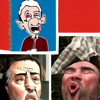

Faint low vibrations and humming


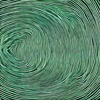

A pig squeezing and male speech


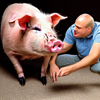

A person whistling followed by pigeons cooing and bird wings flapping as birds chirp in the background


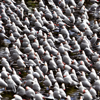

A rattling motor slowly comes to a stop


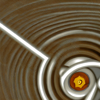

Several gunshots in quick succession


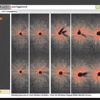

A group of puppies whimpering as cardboard rustles


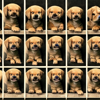

A cup is filled from a faucet


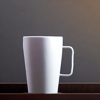

A motorcycle engine running idle then revving


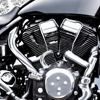

Helicopter rotors slowing down


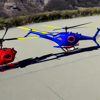

Footsteps shuffling followed by fabric slapping a hard surface as a person heavily breathes


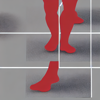

White noise continues then something begins clicking


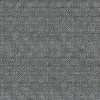

Humming of an idling engine


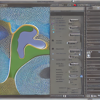

A person snoring during a series of thumps followed by a man talking in the background


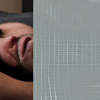

Background rustling followed by a goat screaming


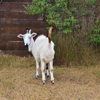

A person speaks, traffic passes by


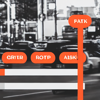

A man talking as an infant is crying followed by a man humming


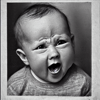

Thunder crashes and rain splashes, during which two adult males speak


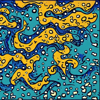

A bus is traveling on the road


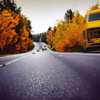

A crowd of people talking as a man hollers and laughs while a group of ducks quack


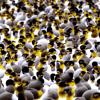

A siren with people talking in the background


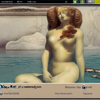

A child cries followed by a man and woman speaking and then the child resumes sobbing


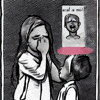

Velcro scrapping off fabric followed as an air ventilation system hums in the background


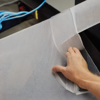

A fire engine with a siren fading then another loud siren


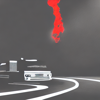

Rustling and distant sanding with nearby ticking and chiming from a coo clock


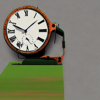

An engine idling followed by the engine revving


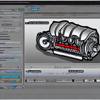

A man talking a sheep speaks while birds chirp in the background and wind blows into a microphone


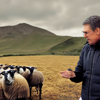

A woman is performing a speech


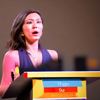

High pitches squealing and a horn blowing with constant humming of an engine


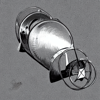

A series of electronic dings while a vehicle horn honks twice followed by a plastic click while a dog barks in the distance


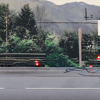

A sneeze occurs followed by sniffling and the start of another sneeze, while a baby coos in the background


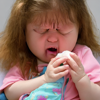

A baby laughing and splashing and a female laughing


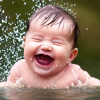

A person snores while people communicate


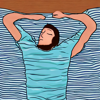

A male voice speaking


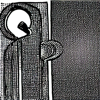

Bird cooing and wings flapping


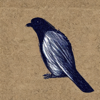

Ticking is ongoing, soft clicking occurs, and a cuckoo calls once followed by musical chimes


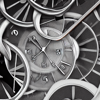

Humming and rattling followed by distant warning bells and the horn of an oncoming train


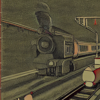

Swiping occurs then a faucet runs and drains


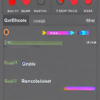

A man shouting as another man talks in the background while a series of gunshots fire and footsteps running on concrete followed by guns cocking and a dog growling


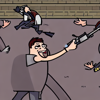

Women talk while food fries


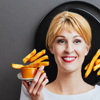

A train running on train tracks while a steam engine horn whistles


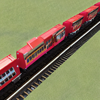

An explosion sounds with bursting noises


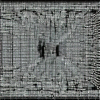

A duck quacks followed by a man talking while birds chirp in the distance


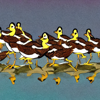

A man speaks then whistles with a playing guitar


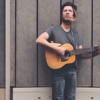

A man speaking with murmuring in the background


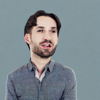

A two-tone electronic alarm is ongoing, while an adult female is speaking in the foreground and birds are chirping in the background


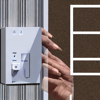

Water rushing and bubbling


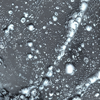

Train horns honking as wind blows into a microphone while a group of people talk and an electronic beep repeatedly sounds during a vehicle engine running idle


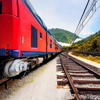

A dog barking as a man is talking while wind blows into a microphone as birds chirp in the distance


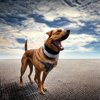

A horse gallops then trot on grass as gusts of wind blow and thunderclaps in the distance


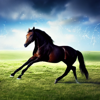

U'A clock ticking followed by a cuckoo bird cooing then music playing.


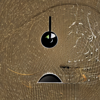

An engine rumbles loudly, then an air horn honk three times


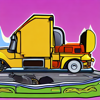

A musical horn


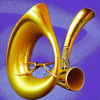

A cat meowing once with a thud


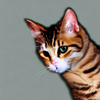

Metal clacking followed by a man talking as metal rattles while light guitar music plays in the background


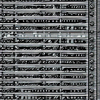

Humming of a nearby jet engine


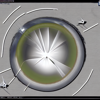

Something bangs and clicks then a man talks and scrapes something


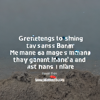

A goat bleating repeatedly


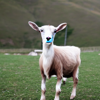

A girl speaks while rain pitter-patters followed by male sneezing


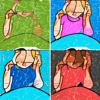

The wind is blowing, an aircraft motor is running, and whirring and the beating of propellers are ongoing


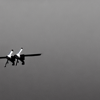

Someone moving around followed by sink water running


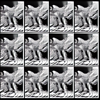

An idle vehicle engine running followed by bird cawing in the background and a plastic camera click


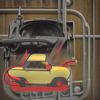

A chainsaw running and crackling


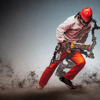

A woman speaks with some light sanding


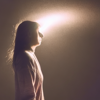

A man speaking and plastic crumpling


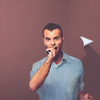

Burping and laughing from a young girl


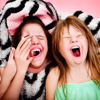

A toy helicopter flying as wind blows into a microphone


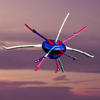

Water is trickling, and a man talks


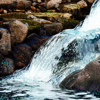

Some rustling with short bursts of vibrations from a sewing machine


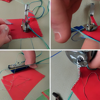

A man is speaking with people talking and whooshing noises in the background


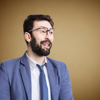

A group of people laughing followed by farting


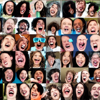

A sewing machine operating several times followed by gears cranking as a man is talking


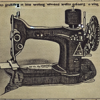

A television plays in the distant background and then a sewing machine starts up


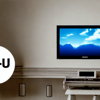

Water is trickling while wind is blowing in the background


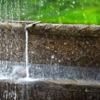

Birds chirping, oinking, and then male speech


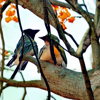

Light rustling followed by faint ticks of a clock


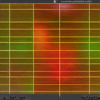

Ducks quack and honk


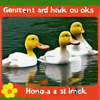

A man speaking and another speaks over the phone


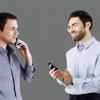

An engine is idling followed by a male speaking


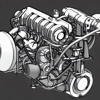

Female speech followed by a thumping noise


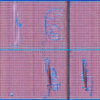

Water lightly splashing as a bird chirps and wind blows into a microphone


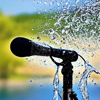

A helicopter engine working


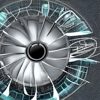

A car horn honks once shortly and then two long honks while another car honks


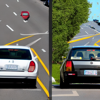

A bus is tooting the horn


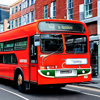

Insects buzzing as a bird is chirping in the distance followed by camera muffling and a person talking then sniffling as footsteps move over foliage


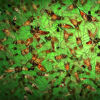

Water lapping in waves as a man talking


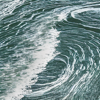

Metal clanking followed by steam hissing as a truck engine is running then accelerating


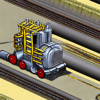

A small motor is running and whirring is occurring, music is ongoing in the background, and an adult female speaks briefly in the background


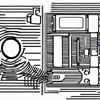

A duck quacks then a man speaks


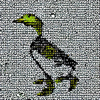

Wind blowing with a man speaking followed by a click and light hum


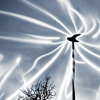

A stream of water trickling as plastic clanks against a metal surface followed by water pouring down a drain alongside a camera muffling


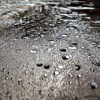

A child speaking and then an adult speaking


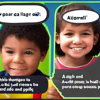

A toilet flushing followed by paper crinkling and a door slamming in the distance


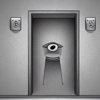

Ducks quack as people communicate


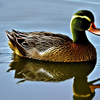

An engine chugging slowly followed by the engine revving


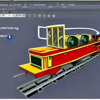

Tapping noise followed by splashing and gurgling water


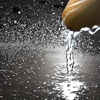

Sustained industrial sawing noise


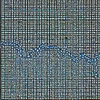

A frog croaking and insects vocalizing with a humming


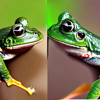

A kid laughing as someone does a series of belching


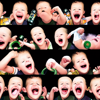

Wind, rain and people talking


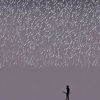

In [ ]:
from IPython.display import display
from PIL import Image

for _, row in sample_df.iterrows():
    img_path = f"images/stable_diffusion/{row['audiocap_id']}/0.png"
    if os.path.exists(img_path):
        print(row['caption'])
        img = Image.open(img_path)
        img = img.resize((100, 100))
        display(img)